In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import kagglehub

c:\Users\owner\Desktop\kaggle\essay-scoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_competition_data(handle:str) -> tuple[pd.DataFrame, pd.DataFrame]:
    local_dir = Path(kagglehub.competition_download(handle))
    train = pd.read_csv(local_dir/"train.csv")
    test = pd.read_csv(local_dir/"test.csv")
    
    return train, test

train,test = load_competition_data("learning-agency-lab-automated-essay-scoring-2")
df = train
print(f"shape : {df.shape}\n{df.dtypes}")

shape : (17307, 3)
essay_id       str
full_text      str
score        int64
dtype: object


In [3]:
TARGET = "score"
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True))

score
3    6280
2    4723
4    3926
1    1252
5     970
6     156
Name: count, dtype: int64
score
3    0.362859
2    0.272895
4    0.226845
1    0.072341
5    0.056047
6    0.009014
Name: proportion, dtype: float64


In [4]:
import os
import nltk
import pandas as pd

nltk_data_dir = r"C:\Users\owner\Desktop\kaggle\essay-scoring\nltk_data"
os.makedirs(nltk_data_dir, exist_ok=True)

for package, resource in (("punkt", "tokenizers/punkt"), ("punkt_tab", "tokenizers/punkt_tab")):
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(package, download_dir=nltk_data_dir, quiet=True)
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)

def _sentence_count(text: str) -> int:
    if not isinstance(text, str):
        return 0
    text = text.strip()
    if not text:
        return 0
    try:
        return len(nltk.sent_tokenize(text))
    except LookupError:
        parts = [segment for segment in text.replace("!", ".").replace("?", ".").split(".") if segment.strip()]
        return len(parts)

df['essay_word_count'] = df['full_text'].fillna("").str.split().str.len()
df['sentence_count'] = df['full_text'].fillna("").map(_sentence_count)
df['sentence_length'] = df['essay_word_count'] / df['sentence_count'].replace(0, pd.NA)
df.head()

,essay_id,full_text,score,essay_word_count,sentence_count,sentence_length
0,000d118,Many people have car where they live. The thin...,3,498,13,38.307692
1,000fe60,I am a scientist at NASA that is discussing th...,3,332,21,15.809524
2,001ab80,People always wish they had the same technolog...,4,550,24,22.916667
3,001bdc0,"We all heard about Venus, the planet without a...",4,451,20,22.550000
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,373,15,24.866667


<Axes: ylabel='Frequency'>

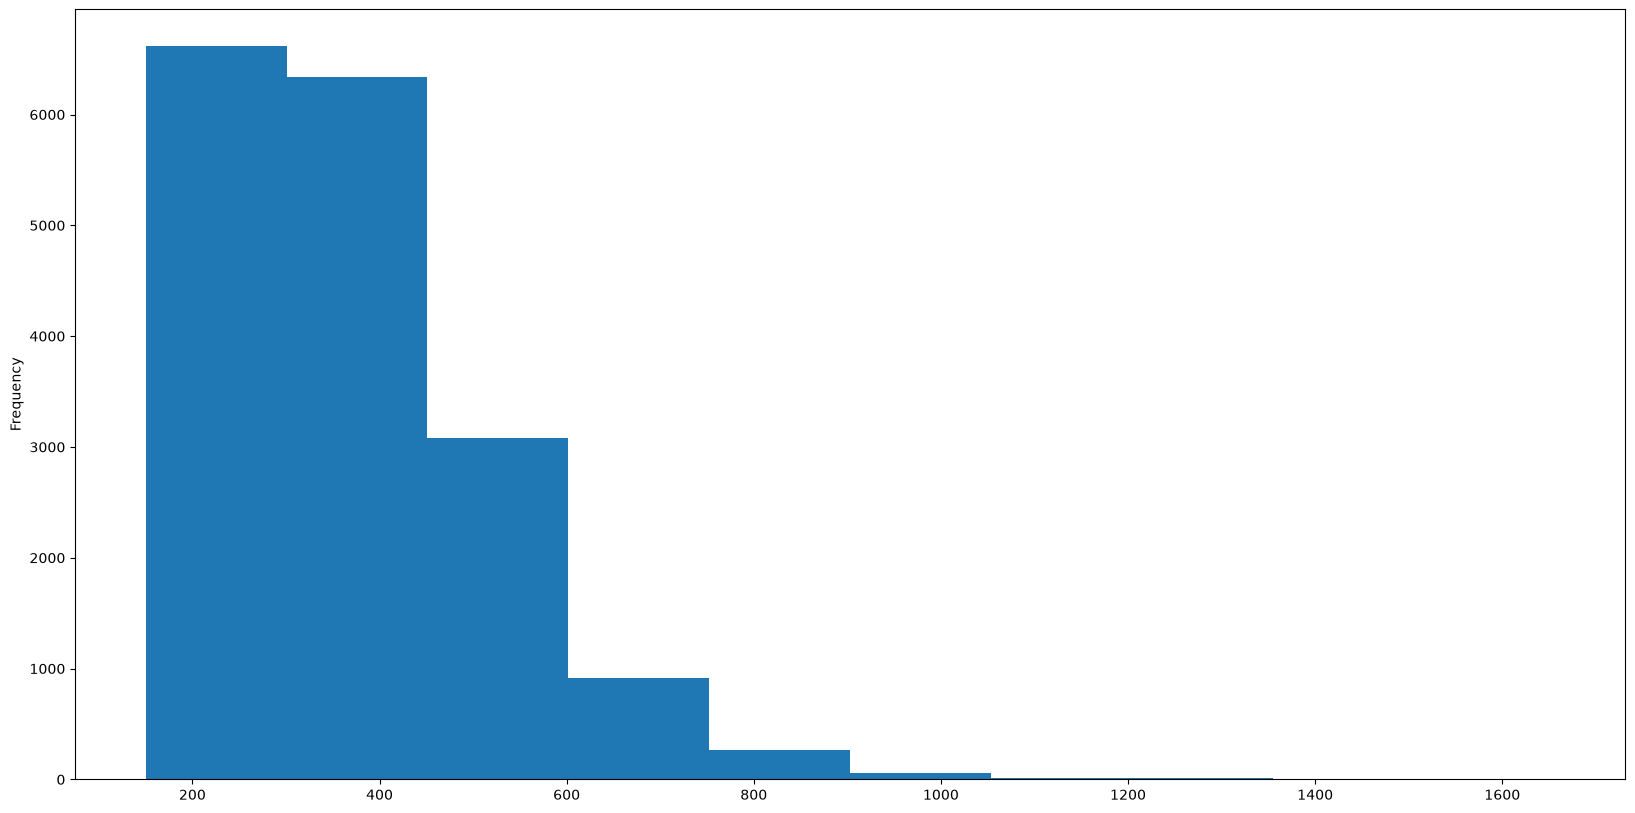

In [6]:
df["essay_word_count"].plot(kind="hist",figsize=(20,10))

<Axes: xlabel='essay_word_count', ylabel='score'>

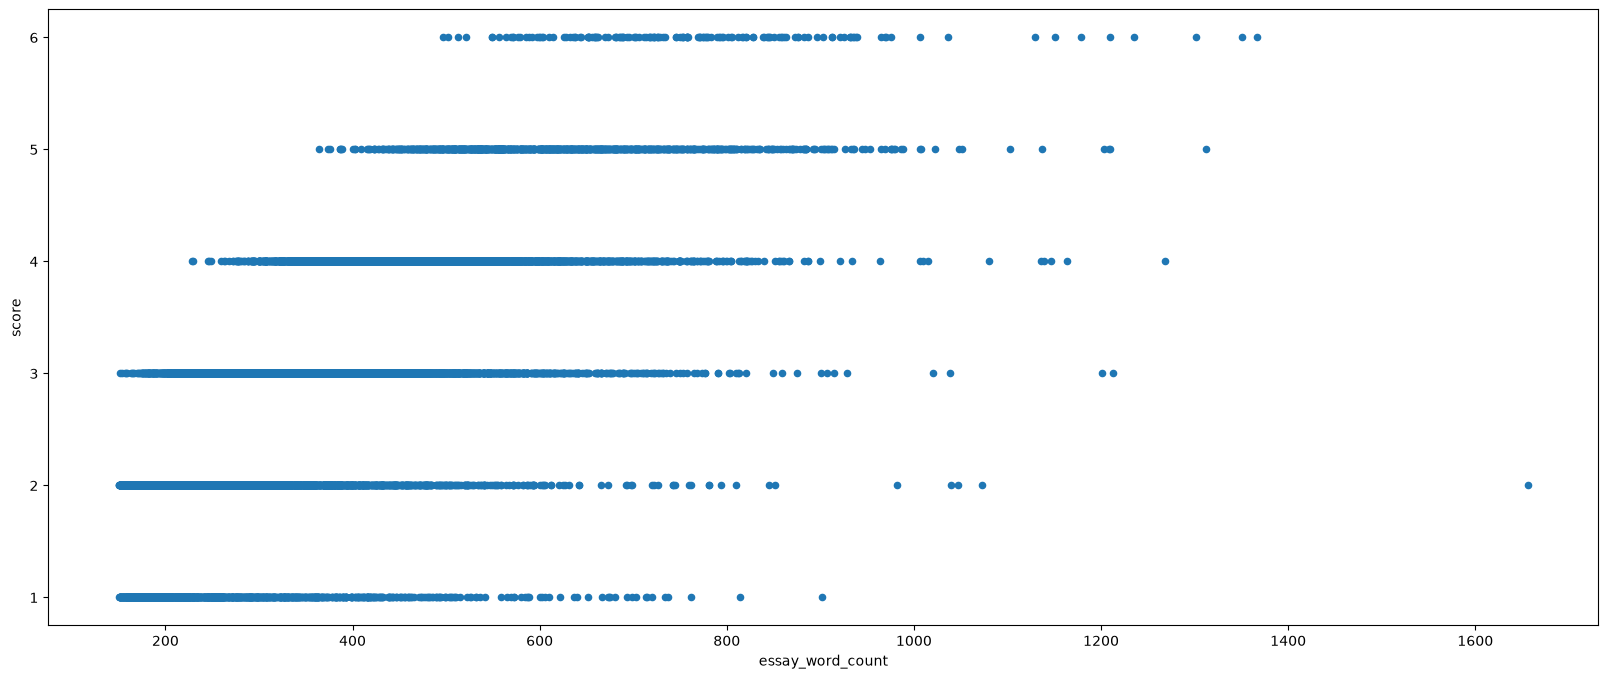

In [7]:
df[["essay_word_count","score"]].plot(kind="scatter",y="score",x="essay_word_count",figsize=(20,8))

<Axes: xlabel='sentence_count', ylabel='score'>

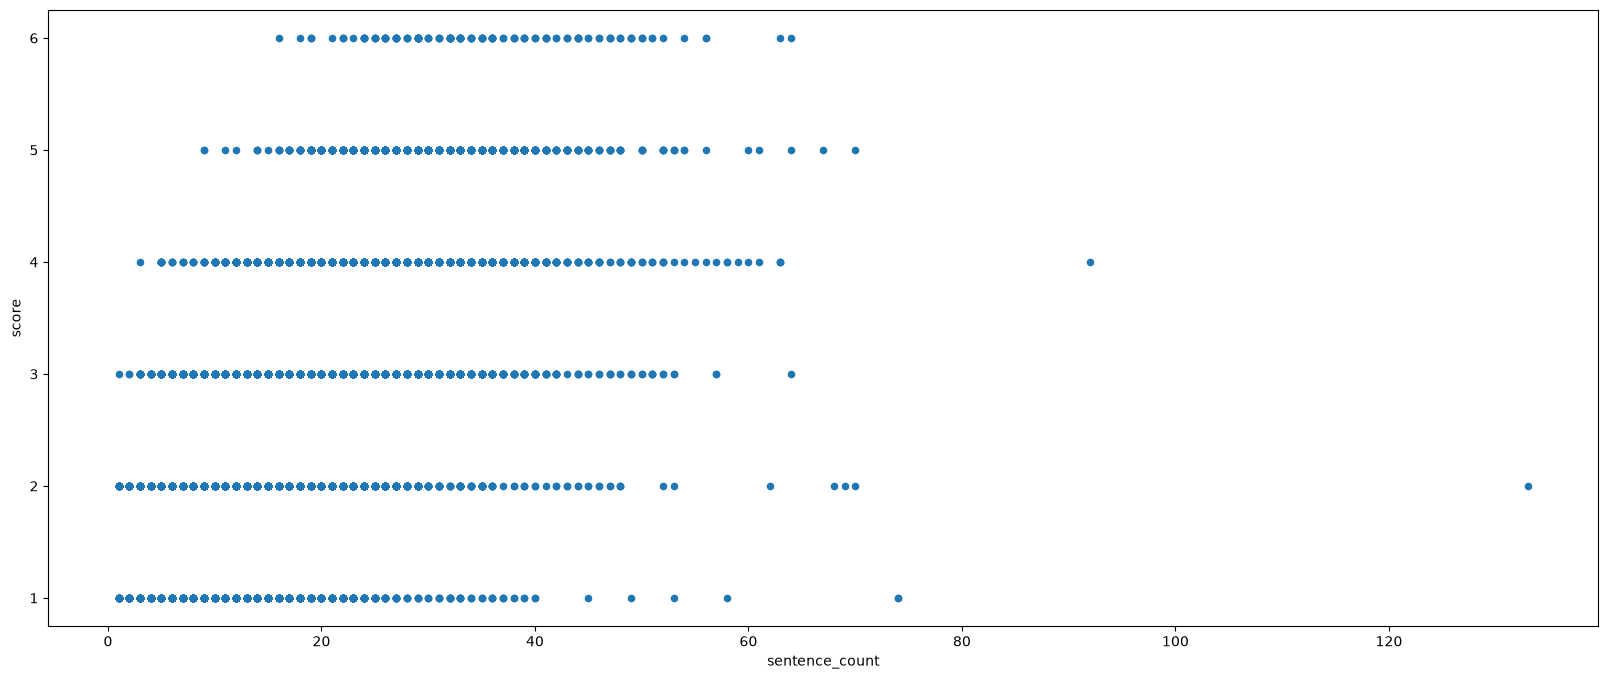

In [8]:
df[["sentence_count","score"]].plot(kind="scatter",y="score",x="sentence_count",figsize=(20,8))

<Axes: xlabel='sentence_length', ylabel='score'>

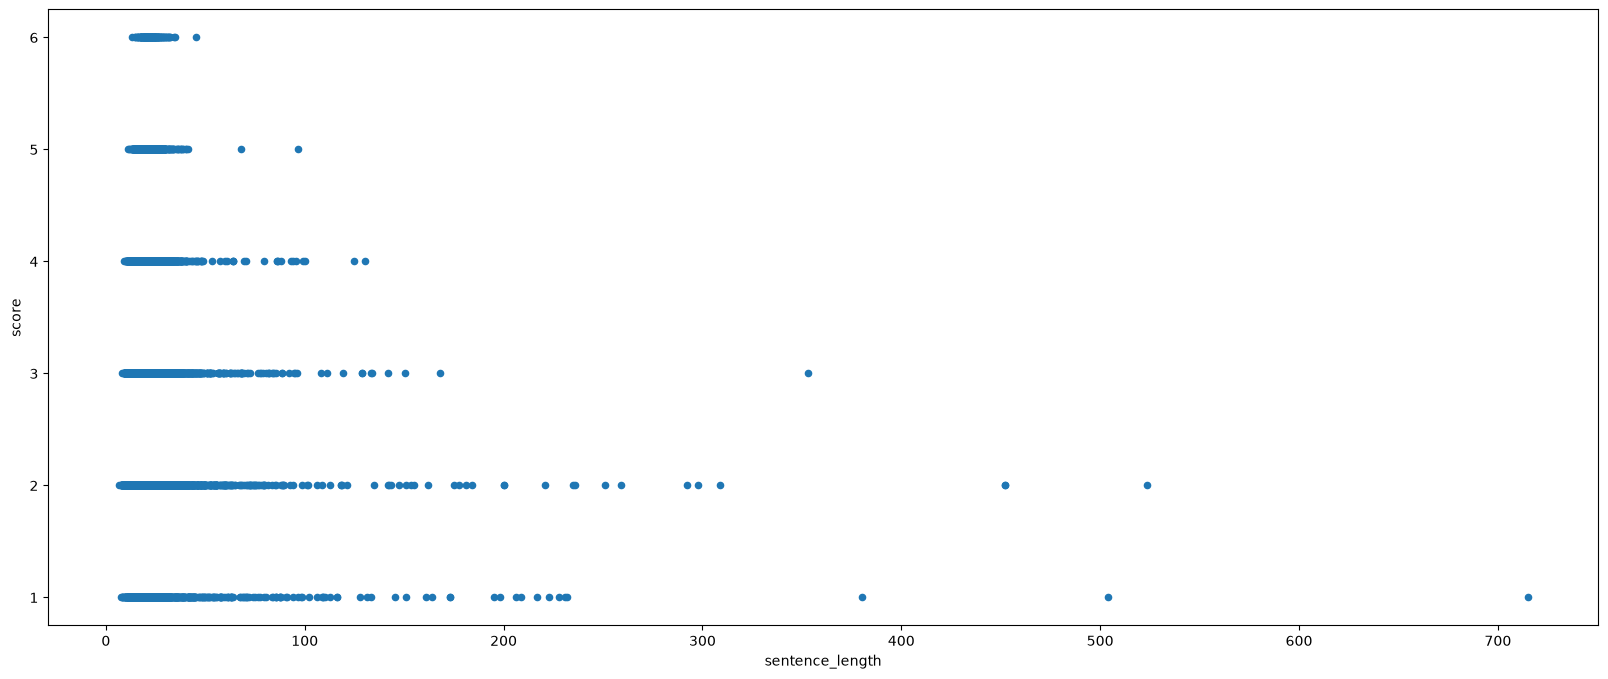

In [10]:
df[["sentence_length","score"]].plot(kind="scatter",y="score",x="sentence_length",figsize=(20,8))